In [15]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import cartopy as cp
import cartopy.feature as cfeature
from matplotlib.patches import FancyArrowPatch

In [10]:
displacements = xr.open_dataset('~/Downloads/displacements.nc')
outlooks = xr.open_dataset('~/Downloads/grid_outlooks.nc')
pph = xr.open_dataset('data/pph/labelled_pph.nc')

In [17]:
pph_key_dict = {
    "Wind": "p_perfect_wind",
    "Hail": "p_perfect_hail",
    "Tornado": "p_perfect_tor",
    "All Hazard": "p_perfect_totalsvr",
}

outlook_key_dict = {
    "Wind": "Day 1 Wind",
    "Hail": "Day 1 Hail",
    "Tornado": "Day 1 Tornado",
    "All Hazard": "Day 1",
}

# risk ordering (include >= threshold)
RISK_ORDER = ["MRGL", "SLGT", "ENH", "MDT", "HIGH"]


def days_at_or_above(pph, threshold):
    """
    Return a boolean mask over pph.time selecting days with MAX_CAT >= threshold.
    Treat HIGH as >= MDT as well via ordering.
    """
    if threshold not in RISK_ORDER:
        raise ValueError(f"threshold must be one of {RISK_ORDER}, got {threshold}")

    allowed = set(RISK_ORDER[RISK_ORDER.index(threshold) :])
    # pph["MAX_CAT"] assumed (time,)
    return pph["MAX_CAT"].isin(list(allowed))


def weighted_composite_displacement(
    displacements,
    outlooks,
    pph,
    hazard,
    threshold,
):
    """
    Compute weighted mean x_flow/y_flow/end_lon/end_lat over days with MAX_CAT >= threshold,
    weighting by outlook probability at each (y,x) on each day.

    Returns:
      mean_x_flow, mean_y_flow, mean_end_lon, mean_end_lat as (y,x) DataArrays,
      plus a (y,x) mask where total weight > 0.
    """
    # --- day selection by risk category ---
    day_mask = days_at_or_above(pph, threshold)  # (time,)
    times_sel = pph["time"].where(day_mask, drop=True)

    if times_sel.size == 0:
        raise ValueError(f"No days found with MAX_CAT >= {threshold} for hazard={hazard}")

    # --- weights: outlook probability for this hazard ---
    w = (
        outlooks.sel(time=times_sel)
        .sel(outlook=outlook_key_dict[hazard])["prob"]  # (time,y,x)
        .astype("float64")
    )

    # --- fields to composite ---
    x_flow = displacements.sel(time=times_sel, hazard=hazard)["x_flow"].astype("float64")  # (time,y,x)
    y_flow = displacements.sel(time=times_sel, hazard=hazard)["y_flow"].astype("float64")
    end_lon = displacements.sel(time=times_sel, hazard=hazard)["end_lon"].astype("float64")
    end_lat = displacements.sel(time=times_sel, hazard=hazard)["end_lat"].astype("float64")

    # ignore days where any component is NaN at a gridpoint
    valid = np.isfinite(x_flow) & np.isfinite(y_flow) & np.isfinite(end_lon) & np.isfinite(end_lat) & np.isfinite(w)

    w_eff = w.where(valid, 0.0)
    denom = w_eff.sum("time")

    mean_x_flow = (x_flow.where(valid, 0.0) * w_eff).sum("time") / denom
    mean_y_flow = (y_flow.where(valid, 0.0) * w_eff).sum("time") / denom
    mean_end_lon = (end_lon.where(valid, 0.0) * w_eff).sum("time") / denom
    mean_end_lat = (end_lat.where(valid, 0.0) * w_eff).sum("time") / denom

    # where denom==0 -> NaN so we don't plot arrows there
    mean_x_flow = mean_x_flow.where(denom > 0)
    mean_y_flow = mean_y_flow.where(denom > 0)
    mean_end_lon = mean_end_lon.where(denom > 0)
    mean_end_lat = mean_end_lat.where(denom > 0)

    return mean_x_flow, mean_y_flow, mean_end_lon, mean_end_lat, (denom > 0)


Tornado | MAX_CAT ≥ MDT
  gridpoints total: 6045
  gridpoints with denom>0: 1017
  finite mean_x: 1017, mean_y: 1017
  finite end_lon: 1017, end_lat: 1017
  arrows to draw: 968


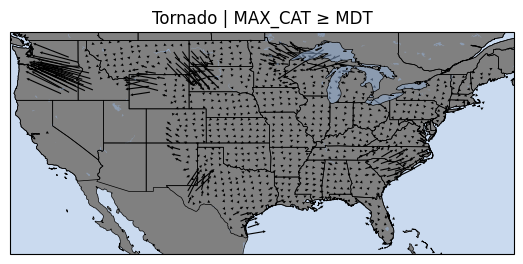


Tornado | MAX_CAT ≥ SLGT
  gridpoints total: 6045
  gridpoints with denom>0: 1305
  finite mean_x: 1305, mean_y: 1305
  finite end_lon: 1305, end_lat: 1305
  arrows to draw: 1217


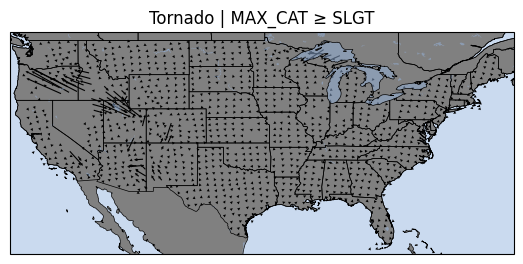


Tornado | MAX_CAT ≥ MRGL
  gridpoints total: 6045
  gridpoints with denom>0: 1316
  finite mean_x: 1316, mean_y: 1316
  finite end_lon: 1316, end_lat: 1316
  arrows to draw: 1225


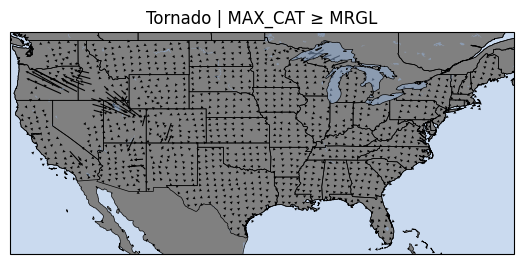


Hail | MAX_CAT ≥ MDT
  gridpoints total: 6045
  gridpoints with denom>0: 1306
  finite mean_x: 1306, mean_y: 1306
  finite end_lon: 1306, end_lat: 1306
  arrows to draw: 1289


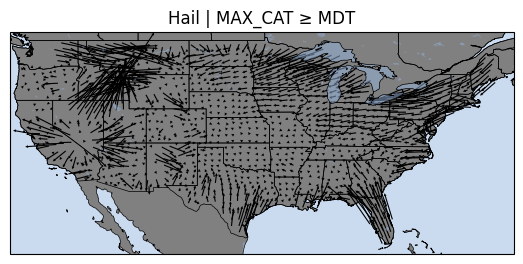


Hail | MAX_CAT ≥ SLGT
  gridpoints total: 6045
  gridpoints with denom>0: 1359
  finite mean_x: 1359, mean_y: 1359
  finite end_lon: 1359, end_lat: 1359
  arrows to draw: 1331


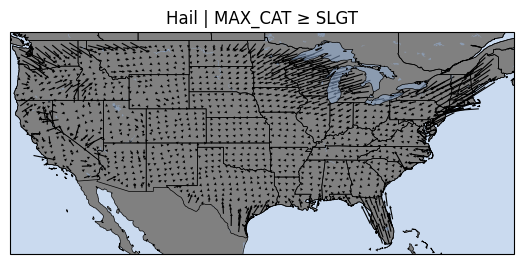


Hail | MAX_CAT ≥ MRGL
  gridpoints total: 6045
  gridpoints with denom>0: 1359
  finite mean_x: 1359, mean_y: 1359
  finite end_lon: 1359, end_lat: 1359
  arrows to draw: 1334


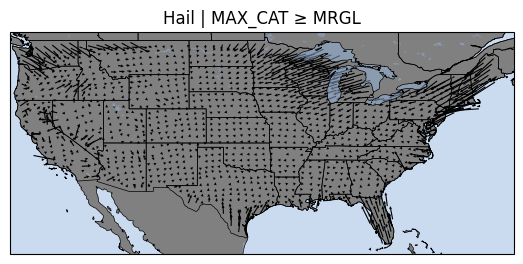


Wind | MAX_CAT ≥ MDT
  gridpoints total: 6045
  gridpoints with denom>0: 1287
  finite mean_x: 1287, mean_y: 1287
  finite end_lon: 1287, end_lat: 1287
  arrows to draw: 1269


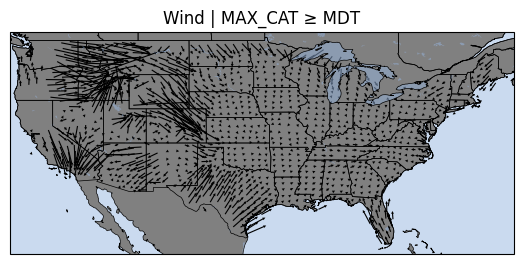


Wind | MAX_CAT ≥ SLGT
  gridpoints total: 6045
  gridpoints with denom>0: 1358
  finite mean_x: 1358, mean_y: 1358
  finite end_lon: 1358, end_lat: 1358
  arrows to draw: 1343


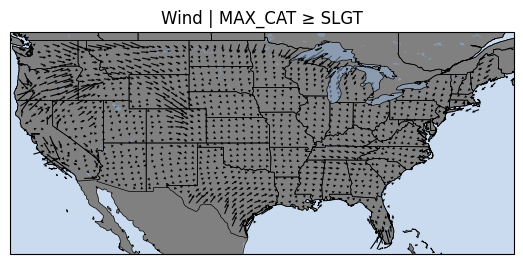


Wind | MAX_CAT ≥ MRGL
  gridpoints total: 6045
  gridpoints with denom>0: 1358
  finite mean_x: 1358, mean_y: 1358
  finite end_lon: 1358, end_lat: 1358
  arrows to draw: 1348


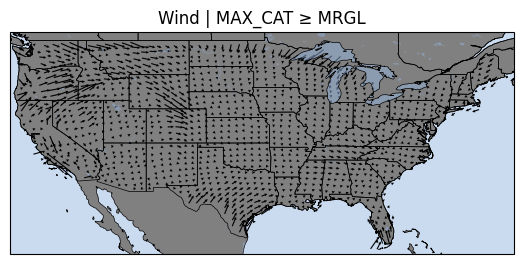


All Hazard | MAX_CAT ≥ MDT
  gridpoints total: 6045
  gridpoints with denom>0: 1311
  finite mean_x: 1311, mean_y: 1311
  finite end_lon: 1311, end_lat: 1311
  arrows to draw: 1293


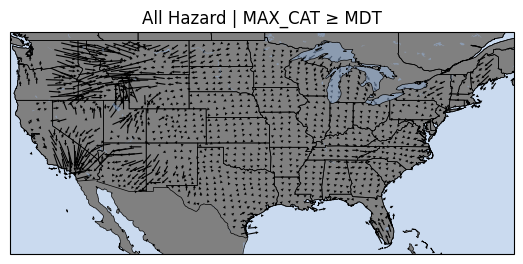


All Hazard | MAX_CAT ≥ SLGT
  gridpoints total: 6045
  gridpoints with denom>0: 1363
  finite mean_x: 1363, mean_y: 1363
  finite end_lon: 1363, end_lat: 1363
  arrows to draw: 1330


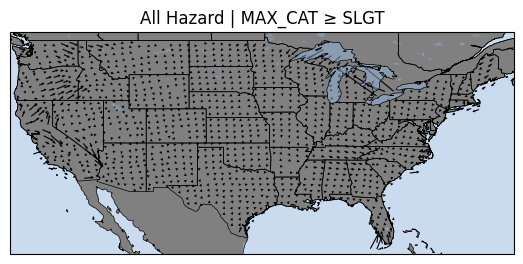


All Hazard | MAX_CAT ≥ MRGL
  gridpoints total: 6045
  gridpoints with denom>0: 1363
  finite mean_x: 1363, mean_y: 1363
  finite end_lon: 1363, end_lat: 1363
  arrows to draw: 1339


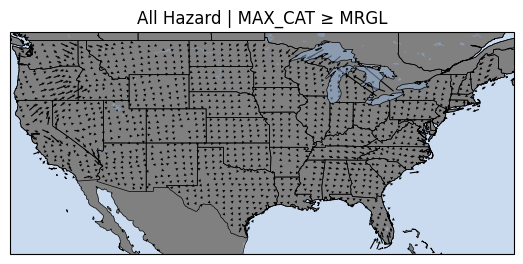

In [19]:
hazards = ["Tornado", "Hail", "Wind", "All Hazard"]
thresholds = ["MDT", "SLGT", "MRGL"]  # shorten while debugging if needed

# base grid for start points
lons = outlooks["lon"].values  # (y,x)
lats = outlooks["lat"].values  # (y,x)

for hazard in hazards:
    for thr in thresholds:

        fig = plt.figure(figsize=(6.5, 4.8))
        ax = plt.axes(projection=cp.crs.PlateCarree())

        # map features
        ax.add_feature(cfeature.LAND, facecolor="grey")
        ax.add_feature(cfeature.OCEAN, alpha=0.5)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.LAKES, alpha=0.5)
        ax.add_feature(cfeature.STATES, linewidth=0.5)
        ax.set_extent([-125, -66, 24, 50], crs=cp.crs.PlateCarree())

        # compute composites
        mean_x, mean_y, mean_end_lon, mean_end_lat, has_weight = weighted_composite_displacement(
            displacements=displacements,
            outlooks=outlooks,
            pph=pph,
            hazard=hazard,
            threshold=thr,
        )

        mx = mean_x.values
        my = mean_y.values
        end_lon = mean_end_lon.values
        end_lat = mean_end_lat.values
        hw = has_weight.values

        # plotting mask (same logic as your single-day example)
        mask = (
            hw
            & np.isfinite(mx) & np.isfinite(my)
            & np.isfinite(end_lon) & np.isfinite(end_lat)
            & (np.abs(mx) > 0.01)
            & (np.abs(my) > 0.01)
        )

        print(f"  arrows to draw: {int(mask.sum())}")

        # draw arrows
        for iy in range(lons.shape[0]):
            for ix in range(lons.shape[1]):
                if not mask[iy, ix]:
                    continue

                ax.add_patch(
                    FancyArrowPatch(
                        (lons[iy, ix], lats[iy, ix]),
                        (end_lon[iy, ix], end_lat[iy, ix]),
                        transform=cp.crs.PlateCarree(),
                        color="black",
                        mutation_scale=4,
                        linewidth=0.005,
                    )
                )

        ax.set_title(f"{hazard} | MAX_CAT ≥ {thr}")

        plt.show()
        plt.close(fig)

In [14]:
displacements

<xarray.Dataset>
Dimensions:    (y: 65, x: 93, time: 16436, hazard: 4)
Coordinates:
  * time       (time) object '197901010000' '197901020000' ... '202312310000'
  * x          (x) float64 0.0 1.0 2.0 3.0 4.0 5.0 ... 88.0 89.0 90.0 91.0 92.0
  * y          (y) float64 0.0 1.0 2.0 3.0 4.0 5.0 ... 60.0 61.0 62.0 63.0 64.0
  * hazard     (hazard) object 'Wind' 'Hail' 'Tornado' 'All Hazard'
Data variables:
    lat        (y, x) float64 ...
    lon        (y, x) float64 ...
    x_flow     (time, y, x, hazard) float64 ...
    y_flow     (time, y, x, hazard) float64 ...
    end_lon    (time, y, x, hazard) float64 ...
    end_lat    (time, y, x, hazard) float64 ...
    e_flow     (time, y, x, hazard) float64 ...
    n_flow     (time, y, x, hazard) float64 ...
    e_shift    (time, hazard) float64 ...
    n_shift    (time, hazard) float64 ...
    total_div  (time, hazard) float64 ...
Attributes:
    description:  Displacements from gridded day 1 probabilistic outlooks to ...
    grid:         80-km NCEP 211